#  Détection de Fraude en Assurance Auto


#  Présentation du dataset — Auto Insurance Claims Data

## Contexte métier

Ce dataset représente un portefeuille de **1000 sinistres auto** déclarés
auprès d'une compagnie d'assurance américaine.

Chaque ligne correspond à **un sinistre déclaré par un assuré**.
L'objectif est de prédire si ce sinistre est frauduleux ou non,
à partir des informations disponibles au moment de la déclaration.

**Variable cible :** `fraud_reported` → Y (fraude) ou N (non-fraude)

---

## Description des variables (40 au total)

Les variables sont regroupées en 4 familles :

---

###  1. Variables sur le profil de l'assuré (7 variables)

| Variable | Description | Exemple |
|:---|:---|:---|
| `months_as_customer` | Ancienneté de l'assuré en mois | 328 |
| `age` | Âge de l'assuré | 48 |
| `insured_sex` | Sexe de l'assuré | MALE / FEMALE |
| `insured_education_level` | Niveau d'études | MD, PhD, High School... |
| `insured_occupation` | Métier de l'assuré | craft-repair, exec-managerial... |
| `insured_hobbies` | Loisirs déclarés | chess, cross-fit, camping... |
| `insured_relationship` | Lien avec le souscripteur | husband, wife, own-child... |

>  `insured_hobbies` est souvent une variable très discriminante
> dans les modèles de fraude — certains loisirs sont statistiquement
> plus associés aux fraudes que d'autres.

---

###  2. Variables sur la police d'assurance (7 variables)

| Variable | Description | Exemple |
|:---|:---|:---|
| `policy_number` | Identifiant unique de la police | 521585 |
| `policy_bind_date` | Date de souscription de la police | 2000-01-01 |
| `policy_state` | État américain de la police | OH, IN, IL |
| `policy_csl` | Limites de garantie combinées | 250/500, 100/300... |
| `policy_deductable` | Franchise  | 1000, 2000... |
| `policy_annual_premium` | Prime annuelle payée | 1406.91 |
| `umbrella_limit` | Garantie complémentaire souscrite  | 0, 3 000 000... |

>  `policy_number` sera **supprimé** au preprocessing :
> c'est un identifiant unique sans aucune valeur prédictive.
> Un modèle qui l'utilise mémoriserait les données au lieu d'apprendre.

---

### 3. Variables sur le sinistre déclaré (13 variables)

| Variable | Description | Exemple |
|:---|:---|:---|
| `incident_date` | Date du sinistre | 2015-01-06 |
| `incident_type` | Nature du sinistre | Single Vehicle Collision, Vehicle Theft... |
| `collision_type` | Type de collision | Rear Collision, Side Collision... |
| `incident_severity` | Gravité du sinistre | Minor Damage, Major Damage, Total Loss... |
| `authorities_contacted` | Autorités contactées | Police, Fire, Ambulance, None |
| `incident_state` | État où le sinistre a eu lieu | SC, VA, WV... |
| `incident_city` | Ville du sinistre | Columbus, Northbend... |
| `incident_location` | Adresse du sinistre | 9935 4th Drive |
| `incident_hour_of_the_day` | Heure du sinistre (0-23) | 5, 14, 23... |
| `number_of_vehicles_involved` | Nombre de véhicules impliqués | 1, 2, 3, 4 |
| `property_damage` | Dégâts matériels sur des tiers | YES / NO |
| `bodily_injuries` | Nombre de blessés déclarés | 0, 1, 2 |
| `witnesses` | Nombre de témoins | 0, 1, 2, 3 |
| `police_report_available` | Rapport de police disponible | YES / NO |

> Variables clés pour la détection de fraude :
> - **`witnesses = 0`** + **`police_report_available = NO`** = fort signal de fraude
> - **`incident_type = Vehicle Theft`** = taux de fraude plus élevé que la moyenne
> - **`incident_severity = Total Loss`** = montant réclamé maximal, plus facile à gonfler

---

### 4. Variables sur les montants réclamés (4 variables)

- **`total_claim_amount`** : Montant total réclamé en dollars — ex : 71610
- **`injury_claim`** : Part blessures en dollars — ex : 5470
- **`property_claim`** : Part dégâts matériels en dollars — ex : 3490
- **`vehicle_claim`** : Part véhicule en dollars — ex : 62650

**Note :** Ces 4 variables sont très corrélées (0.72 à 0.98) car elles sont les composantes de `total_claim_amount`. On supprimera les 3 composantes au preprocessing pour éviter la multicolinéarité.

---
###  5. Variables sur le véhicule assuré (3 variables)

| Variable | Description | Exemple |
|:---|:---|:---|
| `auto_make` | Marque du véhicule | Toyota, Honda, BMW... |
| `auto_model` | Modèle du véhicule | Forrestor, Camry... |
| `auto_year` | Année du véhicule | 1995, 2004, 2015... |

---

###  6. Variable cible (1 variable)

| Variable | Description | Valeurs |
|:---|:---|:---|
| `fraud_reported` | Sinistre frauduleux ? | **Y** (fraude) / **N** (non-fraude) |

---

## Variables qui seront supprimées au preprocessing

| Variable | Raison |
|:---|:---|
| `policy_number` | Identifiant unique, aucune valeur prédictive |
| `policy_bind_date` | Date brute non exploitée |
| `incident_date` | Date brute non exploitée |
| `insured_zip` | Trop spécifique, risque de mémorisation |
| `incident_location` | Idem |
| `_c39` | Colonne vide, artefact du dataset |
| `injury_claim` | Redondante avec `total_claim_amount` |
| `property_claim` | Redondante avec `total_claim_amount` |
| `vehicle_claim` | Redondante avec `total_claim_amount` |
| `age` | Très corrélée à `months_as_customer` (0.92) |

---

## En résumé

> Ce dataset contient **toutes les informations disponibles au moment
> de la déclaration d'un sinistre** : qui est l'assuré, quelle police
> il a souscrite, ce qu'il déclare s'être passé, et combien il réclame.
>
> L'enjeu est d'apprendre automatiquement les **combinaisons de signaux**
> qui caractérisent une fraude — car aucun signal seul n'est suffisant.
> C'est précisément ce que les modèles d'ensemble (Random Forest, XGBoost)
> savent faire mieux que les modèles simples.


## Module 1 — Exploration des données (EDA)

Objectif : comprendre la structure du dataset avant de modéliser.
On cherche à répondre à 3 questions :
1. Les données sont-elles propres ? (valeurs manquantes, types)
2. Les classes sont-elles équilibrées ? (fraude vs non-fraude)
3. Quelles variables semblent discriminantes pour détecter la fraude ?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance_claims.xls")

# Le dataset utilise '?' comme valeur manquante
df.replace("?", np.nan, inplace=True)

print(f"Nombre de sinistres : {df.shape[0]}")
print(f"Nombre de variables  : {df.shape[1]}")
df.head()

Nombre de sinistres : 1000
Nombre de variables  : 40


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,NaN,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 1. Valeurs manquantes

On identifie les colonnes qui ont des données manquantes.
On devra les imputer au preprocessing :
- variable catégorielle → remplacer par le **mode** (valeur la plus fréquente)
- variable numérique → remplacer par la **médiane**

In [2]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Colonnes avec valeurs manquantes :")
print(missing)

Colonnes avec valeurs manquantes :
_c39                       1000
property_damage             360
police_report_available     343
collision_type              178
dtype: int64


## 2. Distribution de la variable cible

La variable cible est `fraud_reported` : Y (fraude) ou N (non-fraude).

**Question clé : les classes sont-elles équilibrées ?**

Si non → un modèle naïf qui prédit toujours "non-fraude" aura quand même
une bonne accuracy. C'est trompeur. C'est pour ça qu'on utilisera
le **Recall** et l'**AUC-ROC** comme métriques, pas l'accuracy.

Non-fraude (N) : 753 sinistres (75.3%)
Fraude (Y)     : 247 sinistres (24.7%)

→ Un modèle naïf qui dit toujours 'non-fraude' aurait 75.3% d'accuracy
→ Conclusion : déséquilibre à corriger avec SMOTE au preprocessing


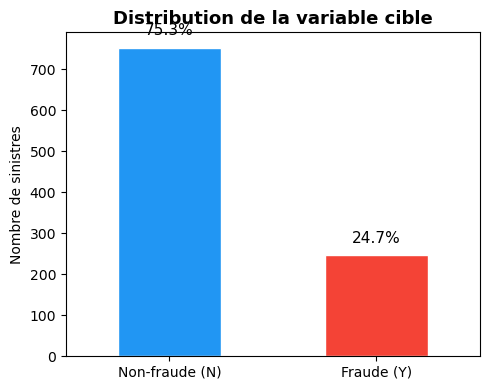

In [3]:
counts = df["fraud_reported"].value_counts()
pct    = df["fraud_reported"].value_counts(normalize=True) * 100

print(f"Non-fraude (N) : {counts['N']} sinistres ({pct['N']:.1f}%)")
print(f"Fraude (Y)     : {counts['Y']} sinistres ({pct['Y']:.1f}%)")
print(f"\n→ Un modèle naïf qui dit toujours 'non-fraude' aurait {pct['N']:.1f}% d'accuracy")
print(f"→ Conclusion : déséquilibre à corriger avec SMOTE au preprocessing")

plt.figure(figsize=(5, 4))
counts.plot(kind="bar", color=["#2196F3", "#F44336"], edgecolor="white")
plt.title("Distribution de la variable cible", fontsize=13, fontweight="bold")
plt.xticks([0, 1], ["Non-fraude (N)", "Fraude (Y)"], rotation=0)
plt.ylabel("Nombre de sinistres")
for i, (v, p) in enumerate(zip(counts, pct)):
    plt.text(i, v + 30, f"{p:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Taux de fraude par variable catégorielle

Pour chaque variable catégorielle, on calcule le taux de fraude
par modalité et on le compare à la moyenne globale (ligne pointillée bleue).

**Une variable est discriminante si** certaines modalités ont un taux
bien au-dessus ou bien en-dessous de la moyenne.

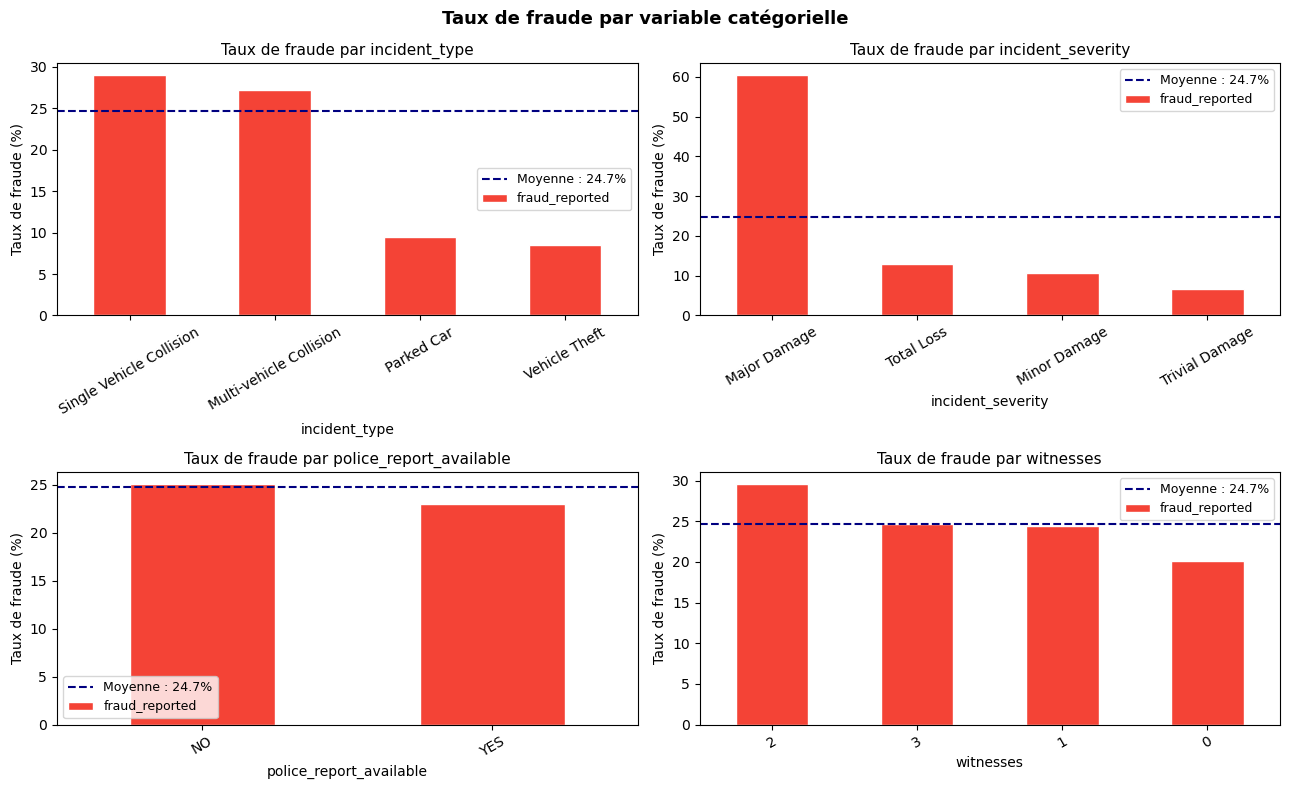

In [4]:
cat_vars = [
    "incident_type",
    "incident_severity",
    "police_report_available",
    "witnesses",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    fraud_rate = (
        df.groupby(col)["fraud_reported"]
        .apply(lambda x: (x == "Y").mean() * 100)
        .sort_values(ascending=False)
    )
    fraud_rate.plot(kind="bar", ax=axes[i], color="#F44336", edgecolor="white")
    axes[i].set_title(f"Taux de fraude par {col}", fontsize=11)
    axes[i].set_ylabel("Taux de fraude (%)")
    axes[i].axhline(y=pct["Y"], color="navy", linestyle="--",
                    linewidth=1.5, label=f"Moyenne : {pct['Y']:.1f}%")
    axes[i].legend(fontsize=9)
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Taux de fraude par variable catégorielle", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Lecture des graphiques :**

- **`incident_type`** : Single Vehicle Collision a le taux le plus élevé (~29%), au-dessus de la moyenne. Vehicle Theft est paradoxalement bas — contrairement à l'intuition, les vols sont moins fraudés dans ce dataset.

- **`incident_severity`** : C'est le graphique le plus intéressant. Major Damage explose à ~60% de fraude, bien au-dessus de la moyenne de 24.7%. Trivial Damage est quasi nul. Logique : les fraudeurs déclarent des dommages graves pour maximiser le montant réclamé.

- **`police_report_available`** : Résultat surprenant — ceux qui ont un rapport de police (YES) ont un taux légèrement plus élevé. On aurait attendu l'inverse. Cette variable est donc moins discriminante que prévu dans ce dataset.

- **`witnesses`** : 2 témoins a le taux le plus élevé, 0 témoin le plus bas. Contre-intuitif — on attendait 0 témoin = plus de fraude. Ce signal ne se confirme pas ici.

**Conclusion :** L'EDA montre que certaines intuitions métier ne se confirment pas toujours dans les données. C'est pour ça qu'on laisse les modèles apprendre les vrais patterns plutôt que de coder des règles manuelles.

## 4. Distribution des montants par statut de fraude

Hypothèse : les fraudeurs gonflent les montants réclamés.
→ On s'attend à voir la distribution des fraudes décalée vers la droite.

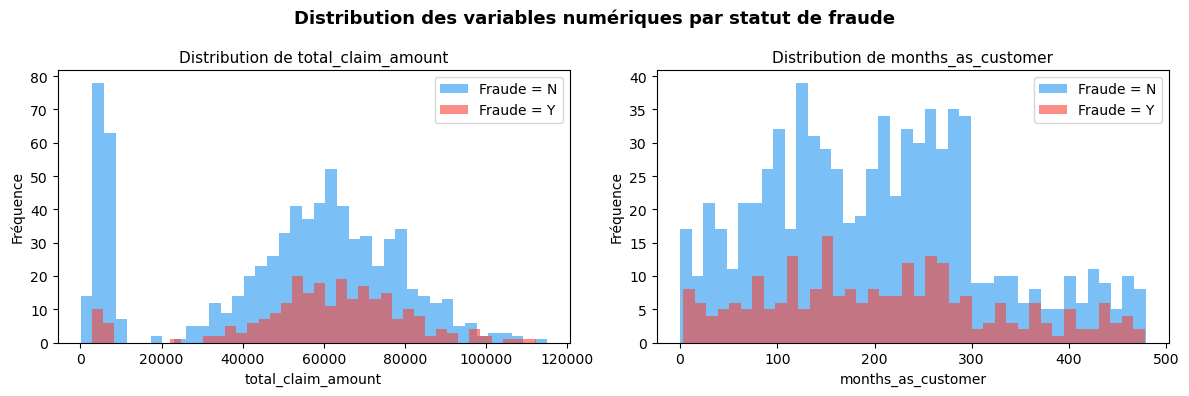

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["total_claim_amount", "months_as_customer"]):
    for label, color in [("N", "#2196F3"), ("Y", "#F44336")]:
        subset = df[df["fraud_reported"] == label][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=f"Fraude = {label}")
    ax.set_title(f"Distribution de {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Fréquence")
    ax.legend()

plt.suptitle("Distribution des variables numériques par statut de fraude",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Matrice de corrélation

On cherche les variables **très corrélées entre elles** (multicolinéarité).

`injury_claim` + `property_claim` + `vehicle_claim` sont les composantes
de `total_claim_amount` → corrélation très forte attendue.
On supprimera les 3 composantes au preprocessing pour éviter la redondance.

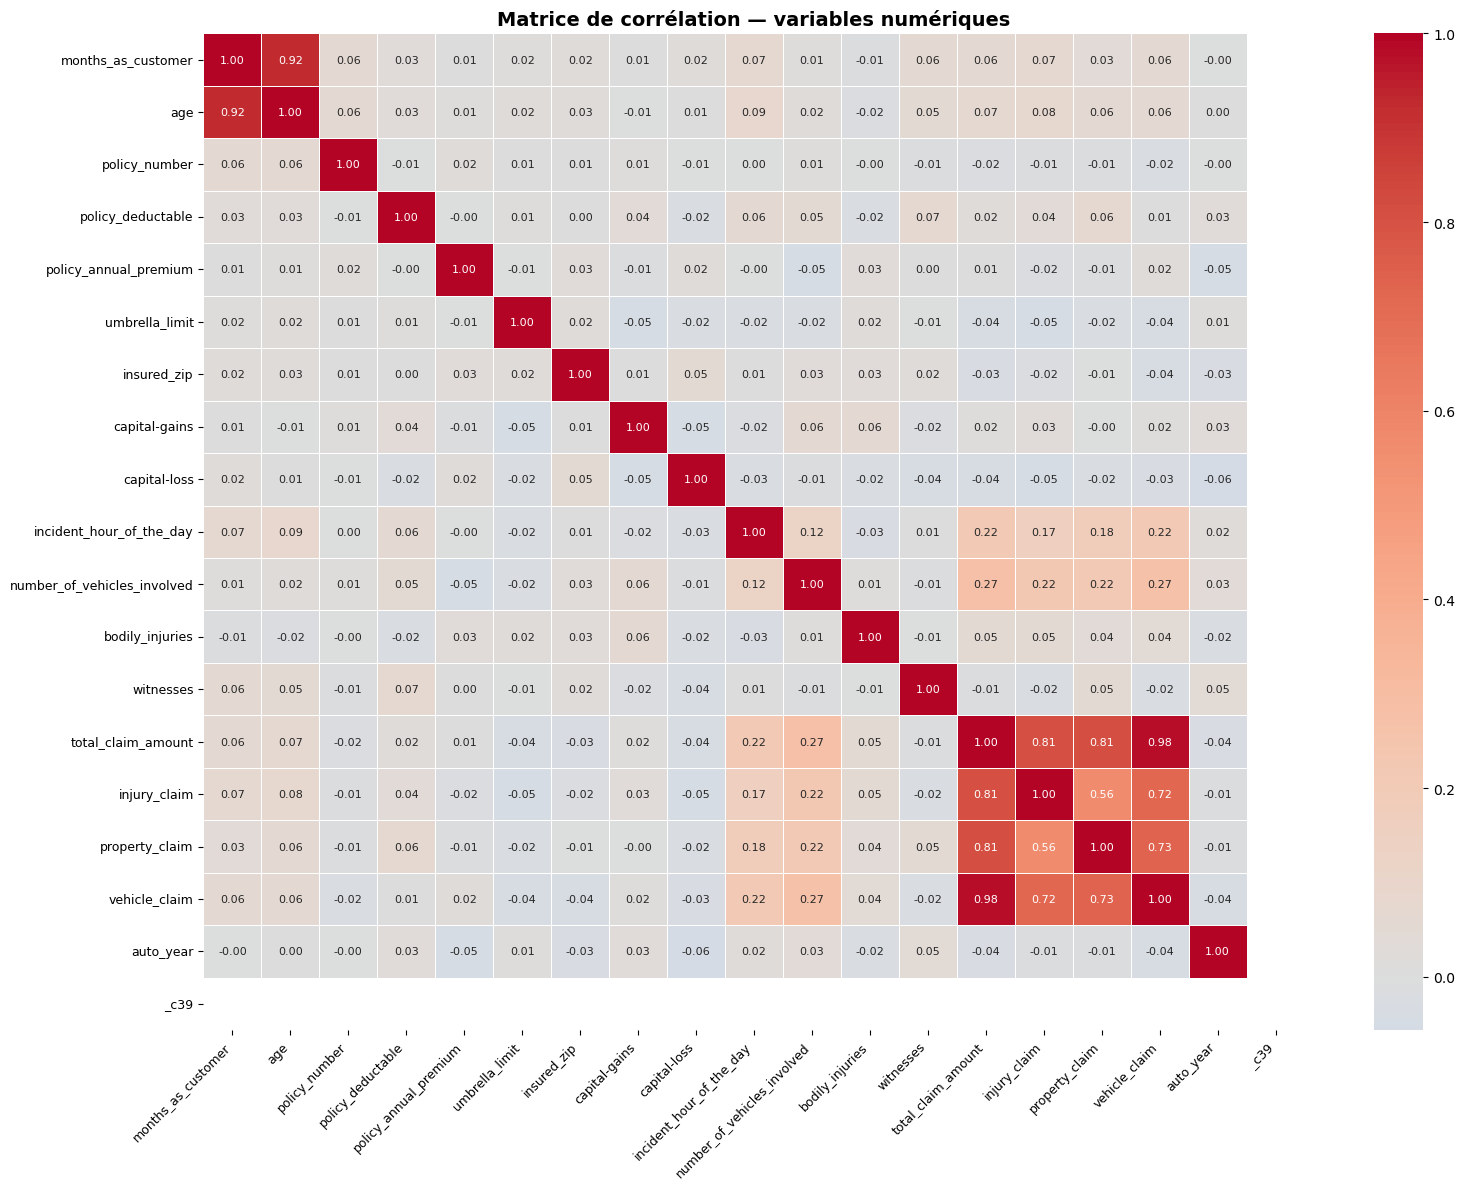

In [6]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Figure beaucoup plus grande + rotation des labels
plt.figure(figsize=(16, 12))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},   # taille des chiffres dans les cases
)
plt.title("Matrice de corrélation — variables numériques", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

##  Bilan Module 1

| Observation | Action au preprocessing |
|:---|:---|
| ~25% de fraudes seulement | Appliquer SMOTE |
| Valeurs `?` dans 3 colonnes | Remplacer par mode/médiane |
| `months_as_customer` et `age` corrélées à 0.92 | Supprimer `age` |
| `injury_claim`, `property_claim`, `vehicle_claim` très corrélées à `total_claim_amount` | Supprimer les 3 composantes |
| Colonnes identifiants (`policy_number`, etc.) | Supprimer |
| Variables discriminantes : `incident_type`, `police_report_available`, `witnesses` | Garder — features importantes |

---


#  Module 2 — Preprocessing

Objectif : préparer les données pour les modèles de machine learning.

Les étapes sont :
1. Suppression des colonnes inutiles
2. Gestion des valeurs manquantes
3. Encodage des variables catégorielles
4. Séparation train / test
5. SMOTE — rééquilibrage des classes
6. Normalisation

## 1. Suppression des colonnes inutiles

On supprime les colonnes qui n'ont aucune valeur prédictive :
- **Identifiants** (`policy_number`) : valeur unique par sinistre, un modèle qui l'utilise mémoriserait les données
- **Dates brutes** (`policy_bind_date`, `incident_date`) : non exploitables telles quelles
- **Localisations trop précises** (`insured_zip`, `incident_location`) : trop spécifiques, risque de mémorisation
- **Colonne vide** (`_c39`) : artefact du dataset
- **Variables redondantes** (`injury_claim`, `property_claim`, `vehicle_claim`) : composantes de `total_claim_amount`, corrélées à 0.98
- **Variable doublon** (`age`) : corrélée à `months_as_customer` à 0.92

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Chargement
df = pd.read_csv("insurance_claims.xls")
df.replace("?", np.nan, inplace=True)

# Colonnes à supprimer
cols_to_drop = [
    "policy_number",       # identifiant unique
    "policy_bind_date",    # date brute
    "incident_date",       # date brute
    "insured_zip",         # trop spécifique
    "incident_location",   # trop spécifique
    "_c39",                # colonne vide
    "injury_claim",        # redondante avec total_claim_amount
    "property_claim",      # redondante avec total_claim_amount
    "vehicle_claim",       # redondante avec total_claim_amount
    "age",                 # corrélée à months_as_customer (0.92)
]

cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Variables restantes : {df.shape[1]}")
print(list(df.columns))

Variables restantes : 30
['months_as_customer', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported']


In [9]:
pip install imbalanced-learn

     -------------------------------------- 258.3/258.3 kB 3.2 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
Note: you may need to restart the kernel to use updated packages.


## 2. Gestion des valeurs manquantes

- Variables catégorielles → on remplace par le **mode** (valeur la plus fréquente)
- Variables numériques → on remplace par la **médiane**

On choisit le mode plutôt que la moyenne pour les catégorielles
car la moyenne n'a pas de sens sur du texte.
On choisit la médiane plutôt que la moyenne pour les numériques
car elle est moins sensible aux valeurs extrêmes (outliers).

In [11]:
# Variables catégorielles → mode
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "fraud_reported"]

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"{col} : {df[col].isnull().sum()} manquantes → remplacées par '{mode_val}'")

# Variables numériques → médiane
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"{col} : valeurs manquantes → remplacées par {median_val}")

print(f"\nValeurs manquantes restantes : {df.isnull().sum().sum()}")

collision_type : 0 manquantes → remplacées par 'Rear Collision'
property_damage : 0 manquantes → remplacées par 'NO'
police_report_available : 0 manquantes → remplacées par 'NO'

Valeurs manquantes restantes : 0


## 3. Encodage des variables catégorielles

Les algorithmes ML ne comprennent pas les textes comme "collision frontale"
ou "avocat". On doit tout convertir en nombres.

On utilise le **Label Encoding** : chaque modalité reçoit un entier.

Exemple :
- `incident_type` : Single Vehicle Collision → 0, Multi-vehicle Collision → 1, etc.
- `fraud_reported` : N → 0, Y → 1

**Note :** Pour la régression logistique, le One-Hot Encoding serait plus rigoureux
pour les variables sans ordre naturel. On garde le Label Encoding ici
par simplicité, ce qui convient bien à Random Forest et XGBoost.

In [12]:
# Encodage de la variable cible en premier
df["fraud_reported"] = df["fraud_reported"].map({"Y": 1, "N": 0})
print("Variable cible : Y=1 (fraude), N=0 (non-fraude)")

# Encodage des variables catégorielles
le_dict = {}
cat_cols_final = df.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols_final:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

print(f"\n{len(cat_cols_final)} variables catégorielles encodées")
print("\nAperçu du dataset après encodage :")
df.head()

Variable cible : Y=1 (fraude), N=0 (non-fraude)

17 variables catégorielles encodées

Aperçu du dataset après encodage :


,months_as_customer,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_hobbies,...,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,auto_make,auto_model,auto_year,fraud_reported
0,328,2,1,1000,1406.91,0,1,4,2,17,...,1,1,1,2,1,71610,10,1,2004,1
1,228,1,1,2000,1197.22,5000000,1,4,6,15,...,1,0,0,0,0,5070,8,12,2007,1
2,134,2,0,2000,1413.14,5000000,0,6,11,2,...,3,0,2,3,0,34650,4,30,2007,0
3,256,0,1,2000,1415.74,6000000,0,6,1,2,...,1,0,1,2,0,63400,3,34,2014,1
4,228,0,2,1000,1583.91,6000000,1,0,11,2,...,1,0,0,1,0,6500,0,31,2009,0


## 4. Séparation train / test

On sépare les données en deux ensembles :
- **Train set (80%)** : données sur lesquelles le modèle apprend
- **Test set (20%)** : données sur lesquelles on évalue le modèle

**Règle absolue : le SMOTE s'applique APRÈS cette séparation.**
Si on applique SMOTE avant, des données synthétiques se retrouvent
dans le test set → l'évaluation est faussée, les performances
sont artificiellement gonflées.

In [13]:
X = df.drop(columns=["fraud_reported"])
y = df["fraud_reported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y    # conserve le même ratio fraude/non-fraude dans train et test
)

print(f"Train set : {X_train.shape[0]} sinistres")
print(f"Test set  : {X_test.shape[0]} sinistres")
print(f"\nTaux de fraude train : {y_train.mean():.1%}")
print(f"Taux de fraude test  : {y_test.mean():.1%}")

Train set : 800 sinistres
Test set  : 200 sinistres

Taux de fraude train : 24.8%
Taux de fraude test  : 24.5%


## 5. SMOTE — rééquilibrage des classes

SMOTE (Synthetic Minority Over-sampling Technique) crée des exemples
synthétiques de la classe minoritaire (fraude) par interpolation
entre exemples existants.

Concrètement : il prend un sinistre frauduleux A, trouve ses voisins
les plus proches parmi les autres fraudes, et crée un nouveau sinistre C
"entre" A et ses voisins — réaliste mais jamais vu par le modèle.

**Appliqué sur le train set uniquement.**

In [14]:
print("Avant SMOTE :")
print(f"  Non-fraude : {(y_train == 0).sum()}")
print(f"  Fraude     : {(y_train == 1).sum()}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAprès SMOTE :")
print(f"  Non-fraude : {(y_train_res == 0).sum()}")
print(f"  Fraude     : {(y_train_res == 1).sum()}")
print(f"\n{X_train_res.shape[0] - X_train.shape[0]} exemples synthétiques créés")

Avant SMOTE :
  Non-fraude : 602
  Fraude     : 198

Après SMOTE :
  Non-fraude : 602
  Fraude     : 602

404 exemples synthétiques créés


## 6. Normalisation

On met toutes les variables numériques à la même échelle
(moyenne = 0, écart-type = 1).

Pourquoi ? Un `total_claim_amount` de 50 000 ne doit pas écraser
un `witnesses` de 2 dans les calculs de la régression logistique.

**Important :** on fait un `fit` sur le train set uniquement,
puis un simple `transform` sur le test set.
Si on fittait sur le test set, on introduirait une fuite d'information.

Random Forest et XGBoost n'ont pas besoin de normalisation,
mais ça ne leur nuit pas.

In [16]:
scaler = StandardScaler()

# fit uniquement sur le train → transform sur les deux
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

print("Normalisation appliquée")
print(f"Shape train : {X_train_scaled.shape}")
print(f"Shape test  : {X_test_scaled.shape}")

Normalisation appliquée
Shape train : (1204, 29)
Shape test  : (200, 29)


## Bilan Module 2

| Etape | Méthode | Pourquoi |
|:---|:---|:---|
| Suppression colonnes | Manuel | Identifiants, dates, redondances |
| Valeurs manquantes | Mode / Médiane | Robuste aux outliers |
| Encodage | Label Encoding | Conversion texte en nombres |
| Train / Test split | 80/20 stratifié | Evaluer sur données non vues |
| Rééquilibrage | SMOTE sur train uniquement | Eviter biais vers non-fraude |
| Normalisation | StandardScaler sur train uniquement | Même échelle pour LogReg |



#  Module 3 — Entraînement des modèles

Objectif : entraîner 4 modèles de complexité croissante et comparer leurs performances.

| Modèle | Famille | Objectif dans ce projet |
|:---|:---|:---|
| Decision Tree | Arbre unique | Montrer le problème d'overfitting |
| Régression Logistique | Linéaire | Baseline interprétable |
| Random Forest | Ensemble - bagging | Robuste, feature importance |
| XGBoost | Ensemble - boosting | Meilleure performance attendue |

## 1. Decision Tree — le problème de l'overfitting

Un arbre de décision sans contrainte va pousser jusqu'à avoir
une feuille par sinistre — il mémorise les données au lieu d'apprendre.

Résultat attendu :
- AUC sur le train : ~1.0 (parfait... trop parfait)
- AUC sur le test  : bien plus faible

C'est la définition de l'overfitting.

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Decision Tree — sans contrainte (overfitting volontaire)
# ---------------------------------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

auc_train_dt = roc_auc_score(y_train_res, dt.predict_proba(X_train_res)[:, 1])
auc_test_dt  = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

print("DECISION TREE")
print(f"  AUC train : {auc_train_dt:.4f}")
print(f"  AUC test  : {auc_test_dt:.4f}")
print(f"  Ecart     : {auc_train_dt - auc_test_dt:.4f} ← overfitting")

DECISION TREE
  AUC train : 1.0000
  AUC test  : 0.7131
  Ecart     : 0.2869 ← overfitting


In [19]:
pip install xgboost

     -------------------------------------- 124.9/124.9 MB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


AUC train : 1.0000  → le modèle a mémorisé 100% des données d'entraînement
AUC test  : 0.7131  → sur des données jamais vues, il tombe à 0.71
Ecart     : 0.2869  → énorme, c'est l'overfitting

## 2. Régression Logistique — la baseline

Premier modèle sérieux. Simple, interprétable, accepté par les régulateurs.
On utilise les données normalisées (X_train_scaled) car la régression
logistique est sensible aux échelles.

C'est notre point de référence — tous les autres modèles doivent faire mieux.

In [21]:
# ---------------------------------------------------
# Régression Logistique — données normalisées
# ---------------------------------------------------
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_res)

auc_train_lr = roc_auc_score(y_train_res, lr.predict_proba(X_train_scaled)[:, 1])
auc_test_lr  = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])

print("REGRESSION LOGISTIQUE")
print(f"  AUC train : {auc_train_lr:.4f}")
print(f"  AUC test  : {auc_test_lr:.4f}")
print(f"  Ecart     : {auc_train_lr - auc_test_lr:.4f}")

REGRESSION LOGISTIQUE
  AUC train : 0.8872
  AUC test  : 0.7921
  Ecart     : 0.0951


## 3. Random Forest — ensemble par bagging

On construit 200 arbres de décision indépendants, chacun entraîné
sur un sous-échantillon aléatoire des données et des variables.

La prédiction finale = vote majoritaire des 200 arbres.

Pourquoi c'est mieux qu'un seul arbre ?
→ La diversité des arbres compense les erreurs individuelles.
→ Naturellement résistant à l'overfitting.

In [22]:
# ---------------------------------------------------
# Random Forest — 200 arbres, données non normalisées
# ---------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,    # nombre d'arbres
    max_depth=15,        # profondeur max pour limiter l'overfitting
    min_samples_leaf=5,  # min 5 sinistres par feuille
    random_state=42,
    n_jobs=-1            # utilise tous les coeurs disponibles
)
rf.fit(X_train_res, y_train_res)

auc_train_rf = roc_auc_score(y_train_res, rf.predict_proba(X_train_res)[:, 1])
auc_test_rf  = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print("RANDOM FOREST")
print(f"  AUC train : {auc_train_rf:.4f}")
print(f"  AUC test  : {auc_test_rf:.4f}")
print(f"  Ecart     : {auc_train_rf - auc_test_rf:.4f}")

RANDOM FOREST
  AUC train : 0.9937
  AUC test  : 0.8321
  Ecart     : 0.1616


## 4. XGBoost — ensemble par boosting

Contrairement à Random Forest qui construit les arbres en parallèle,
XGBoost les construit en séquence : chaque arbre corrige les erreurs
du précédent.

Paramètres clés :
- `learning_rate=0.05` : chaque arbre corrige peu à la fois → apprentissage progressif
- `n_estimators=300` : 300 arbres séquentiels
- `max_depth=6` : arbres peu profonds pour éviter l'overfitting
- `scale_pos_weight=3` : compense le déséquilibre résiduel

In [23]:
# ---------------------------------------------------
# XGBoost — boosting séquentiel
# ---------------------------------------------------
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,          # 80% des données par arbre
    colsample_bytree=0.8,   # 80% des variables par arbre
    scale_pos_weight=3,     # gestion du déséquilibre
    eval_metric="logloss",
    random_state=42,
    verbosity=0
)
xgb.fit(X_train_res, y_train_res)

auc_train_xgb = roc_auc_score(y_train_res, xgb.predict_proba(X_train_res)[:, 1])
auc_test_xgb  = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print("XGBOOST")
print(f"  AUC train : {auc_train_xgb:.4f}")
print(f"  AUC test  : {auc_test_xgb:.4f}")
print(f"  Ecart     : {auc_train_xgb - auc_test_xgb:.4f}")

XGBOOST
  AUC train : 1.0000
  AUC test  : 0.8120
  Ecart     : 0.1880


## Récapitulatif — comparaison rapide des AUC

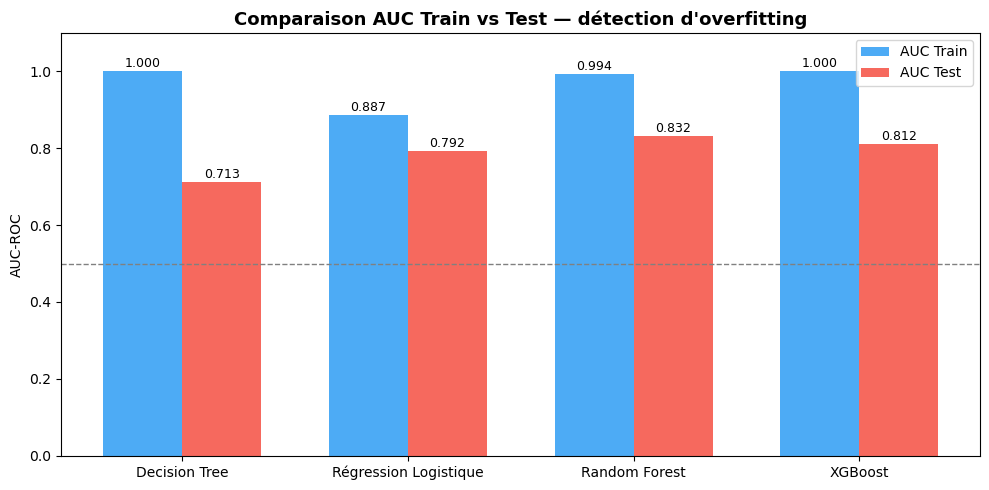

In [24]:
import matplotlib.pyplot as plt

modeles = ["Decision Tree", "Régression Logistique", "Random Forest", "XGBoost"]
auc_train = [auc_train_dt, auc_train_lr, auc_train_rf, auc_train_xgb]
auc_test  = [auc_test_dt,  auc_test_lr,  auc_test_rf,  auc_test_xgb]

x = range(len(modeles))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], auc_train, width, label="AUC Train", color="#2196F3", alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], auc_test,  width, label="AUC Test",  color="#F44336", alpha=0.8)

# Afficher les valeurs sur les barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(modeles, fontsize=10)
ax.set_ylabel("AUC-ROC")
ax.set_ylim(0, 1.1)
ax.set_title("Comparaison AUC Train vs Test — détection d'overfitting", fontsize=13, fontweight="bold")
ax.legend()
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Modèle aléatoire")
plt.tight_layout()
plt.show()

## Bilan Module 3

| Modèle | AUC Train | AUC Test | Ecart |
|:---|:---|:---|:---|
| Decision Tree | 1.0000 | 0.7131 | 0.2869 |
| Régression Logistique | 0.8872 | 0.7921 | 0.0951 |
| XGBoost | 1.0000 | 0.8120 | 0.1880 |
| Random Forest | 0.9937 | 0.8321 | 0.1616 |

**Decision Tree** : AUC train parfait à 1.0 vs AUC test à 0.71 — overfitting
sévère confirmé. L'arbre a mémorisé les données au lieu d'apprendre.

**Régression Logistique** : modèle le plus stable (écart 0.09).
Limité par sa nature linéaire mais généralise bien.

**XGBoost** : overfitte aussi (écart 0.19) mais performe mieux que
la baseline grâce à sa régularisation intégrée.

**Random Forest** : meilleur modèle sur ce dataset avec AUC test = 0.83.
Moins d'overfitting que XGBoost car le bagging diversifie naturellement
les arbres. Sur un dataset plus grand, XGBoost reprendrait l'avantage.



#  Module 4 — Evaluation complète des modèles

L'accuracy seule ne suffit pas sur un dataset déséquilibré.
On évalue chaque modèle sur 4 métriques complémentaires :

- **Recall** : parmi toutes les vraies fraudes, combien a-t-on détectées ?
  → Métrique prioritaire : manquer une fraude coûte cher à l'assureur
- **Precision** : parmi les fraudes détectées, combien sont vraiment des fraudes ?
  → Eviter de suspecter trop de clients honnêtes
- **F1-Score** : compromis entre Recall et Precision
- **AUC-ROC** : capacité discriminante globale, indépendante du seuil

## 1. Tableau comparatif des métriques

In [25]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import pandas as pd

# Dictionnaire modèles → (modèle, X_test à utiliser)
modeles = {
    "Decision Tree"        : (dt,  X_test),
    "Régression Logistique": (lr,  X_test_scaled),
    "Random Forest"        : (rf,  X_test),
    "XGBoost"              : (xgb, X_test),
}

resultats = []

for nom, (modele, X_te) in modeles.items():
    y_pred  = modele.predict(X_te)
    y_proba = modele.predict_proba(X_te)[:, 1]

    resultats.append({
        "Modèle"    : nom,
        "Accuracy"  : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred, zero_division=0),
        "Recall"    : recall_score(y_test, y_pred),
        "F1-Score"  : f1_score(y_test, y_pred),
        "AUC-ROC"   : roc_auc_score(y_test, y_proba),
    })

df_res = pd.DataFrame(resultats).sort_values("Recall", ascending=False).reset_index(drop=True)
df_res.set_index("Modèle", inplace=True)
df_res.round(4)

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modèle,,,,,
XGBoost,0.795,0.5690,0.6735,0.6168,0.8120
Random Forest,0.805,0.6000,0.6122,0.6061,0.8321
Decision Tree,0.775,0.5370,0.5918,0.5631,0.7131
Régression Logistique,0.745,0.4828,0.5714,0.5234,0.7921


## 2. Matrices de confusion

La matrice de confusion montre en détail les erreurs du modèle :

- **Vrai Négatif (TN)** : non-fraude prédit non-fraude 
- **Vrai Positif (TP)** : fraude prédit fraude 
- **Faux Positif (FP)** : non-fraude prédit fraude, client suspecté à tort
- **Faux Négatif (FN)** : fraude prédit non-fraude, fraude manquée → le pire cas

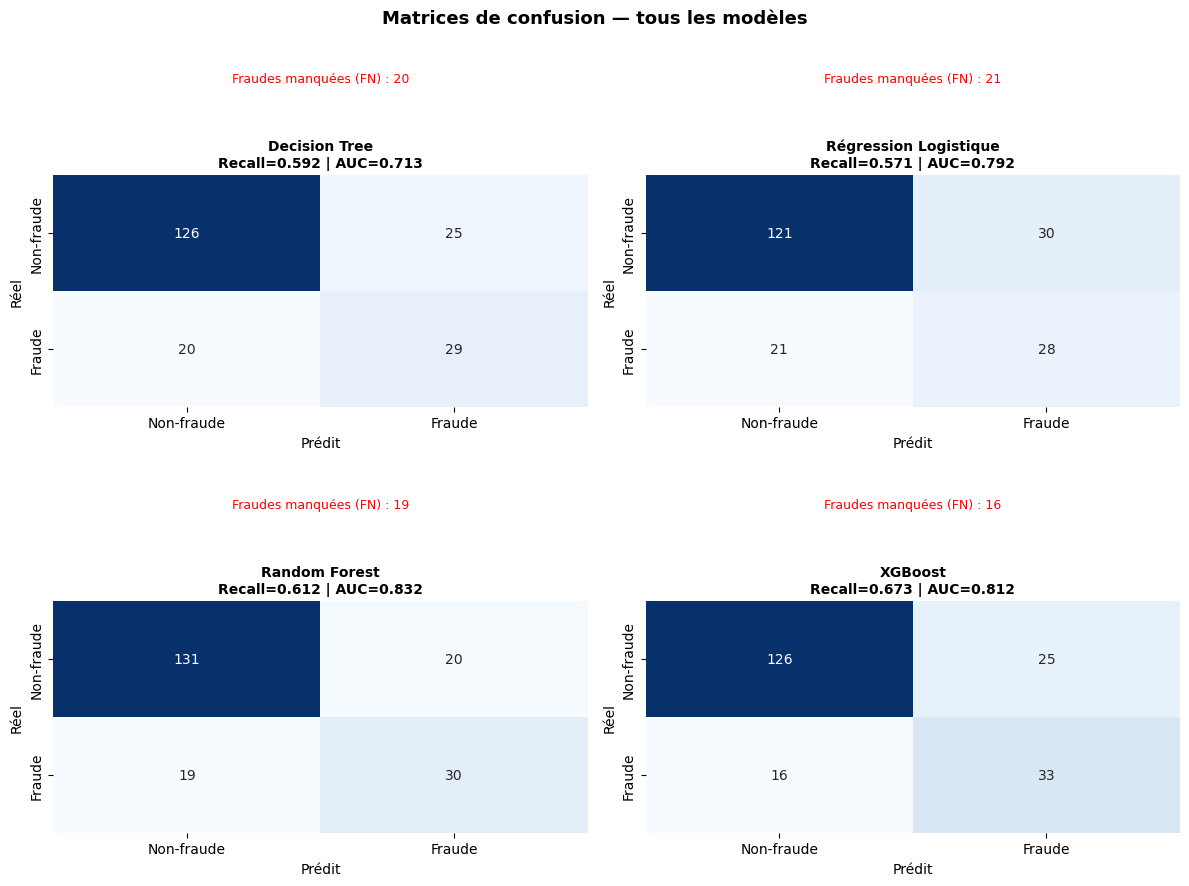

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (nom, (modele, X_te)) in enumerate(modeles.items()):
    y_pred = modele.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
        xticklabels=["Non-fraude", "Fraude"],
        yticklabels=["Non-fraude", "Fraude"],
        cbar=False
    )

    recall = recall_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, modele.predict_proba(X_te)[:, 1])
    fn     = cm[1, 0]

    axes[i].set_title(f"{nom}\nRecall={recall:.3f} | AUC={auc:.3f}", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Prédit")
    axes[i].set_ylabel("Réel")
    axes[i].text(0.5, 1.4, f"Fraudes manquées (FN) : {fn}",
                 ha="center", color="red", fontsize=9,
                 transform=axes[i].transAxes)

plt.suptitle("Matrices de confusion — tous les modèles", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Courbes ROC

La courbe ROC montre le compromis entre :
- **TPR (Recall)** : taux de vraies fraudes détectées
- **FPR** : taux de clients honnêtes suspectés à tort

Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle.
La diagonale pointillée = modèle aléatoire (AUC = 0.5).

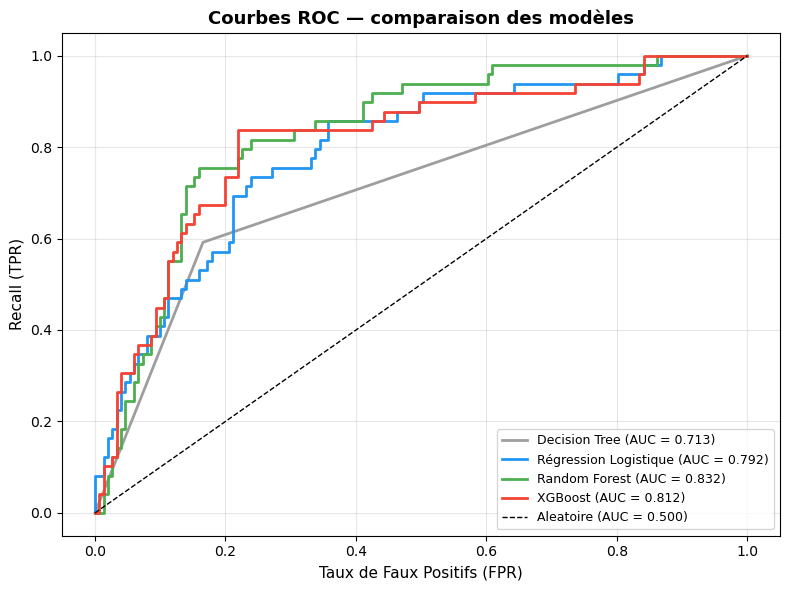

In [27]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#9E9E9E", "#2196F3", "#4CAF50", "#F44336"]

for (nom, (modele, X_te)), color in zip(modeles.items(), colors):
    y_proba = modele.predict_proba(X_te)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{nom} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Aleatoire (AUC = 0.500)")
ax.set_xlabel("Taux de Faux Positifs (FPR)", fontsize=11)
ax.set_ylabel("Recall (TPR)", fontsize=11)
ax.set_title("Courbes ROC — comparaison des modèles", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Feature Importance

Quelles variables sont les plus utiles pour détecter la fraude ?

Random Forest et XGBoost calculent automatiquement l'importance
de chaque variable — c'est l'une de leurs forces majeures.

C'est précieux en assurance : on peut expliquer aux équipes métier
quels signaux sont les plus révélateurs d'un sinistre frauduleux.

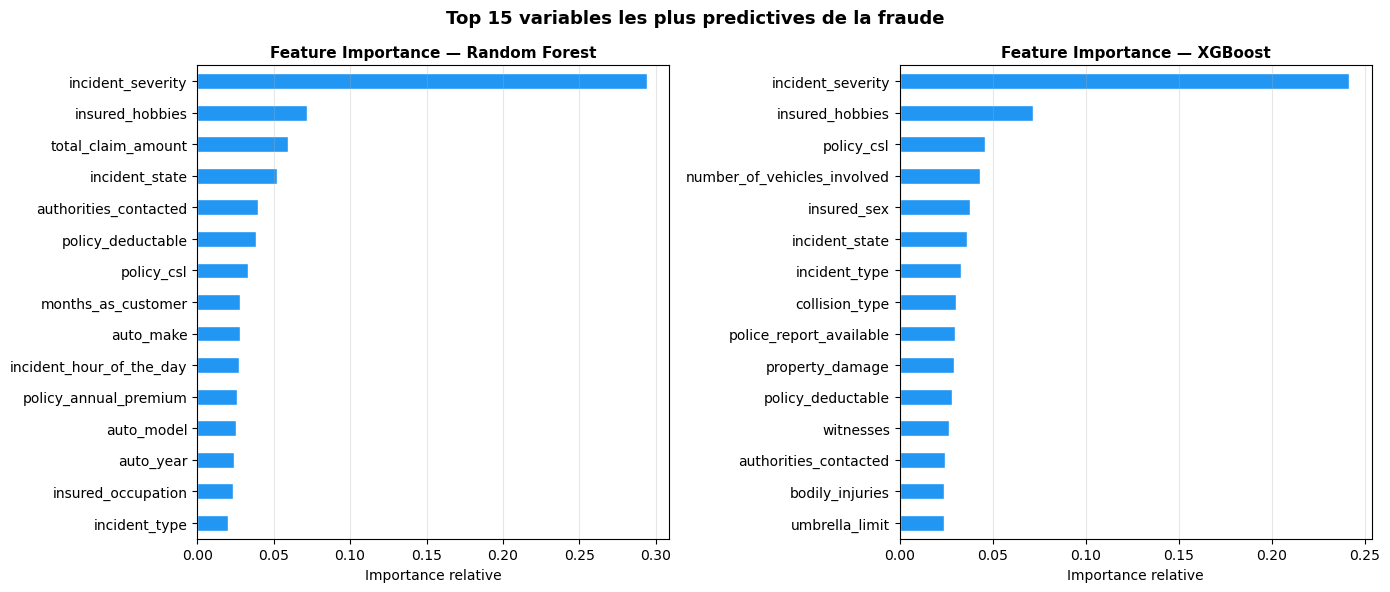

In [28]:
feature_names = list(X_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nom, modele) in zip(axes, [("Random Forest", rf), ("XGBoost", xgb)]):
    importances = pd.Series(modele.feature_importances_, index=feature_names)
    top15 = importances.sort_values(ascending=True).tail(15)

    top15.plot(kind="barh", ax=ax, color="#2196F3", edgecolor="white")
    ax.set_title(f"Feature Importance — {nom}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Importance relative")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Top 15 variables les plus predictives de la fraude",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Bilan final du projet

### Résultats des modèles

| Modèle | Recall | AUC-ROC | Fraudes manquées |
|:---|:---|:---|:---|
| Decision Tree | 0.592 | 0.713 | 20 sur 49 |
| Régression Logistique | 0.571 | 0.792 | 21 sur 49 |
| Random Forest | 0.612 | 0.832 | 19 sur 49 |
| XGBoost | 0.673 | 0.812 | 16 sur 49 |

---

### Quel est le meilleur modèle ?

Selon la métrique choisie, la réponse diffère :

- **Meilleur AUC-ROC** : Random Forest (0.832) — meilleure capacité discriminante globale
- **Meilleur Recall** : XGBoost (0.673) — détecte le plus de fraudes, manque seulement 16 sinistres sur 49

En contexte assurantiel, **XGBoost est le modèle retenu** car le Recall
est la métrique prioritaire : manquer une fraude a un coût financier
direct pour l'assureur.

---

### Variables les plus prédictives

Les deux modèles s'accordent sur le top 2 :

1. **`incident_severity`** : les fraudeurs déclarent systématiquement
   des dommages graves pour maximiser le remboursement
2. **`insured_hobbies`** : certains loisirs déclarés sont statistiquement
   très corrélés à la fraude — signal non intuitif détecté automatiquement
   par les modèles, qu'un expert humain n'aurait pas codé manuellement

---

### Limites du projet

- **Dataset limité** : 1000 sinistres seulement — les résultats sont
  à confirmer sur un volume plus important. Sur un grand dataset,
  XGBoost prendrait probablement l'avantage sur Random Forest en AUC également.

- **Seuil de classification** : le seuil par défaut de 0.5 est un choix
  arbitraire. En production, l'assureur calibrerait ce seuil selon le coût
  relatif d'un faux négatif (fraude manquée) vs faux positif (client suspecté
  à tort) — c'est une décision métier, pas technique.

- **Interprétabilité** : Random Forest et XGBoost sont des boites noires
  partielles. En production, des outils comme SHAP permettraient d'expliquer
  chaque prédiction individuelle au régulateur — essentiel dans le cadre
  de Solvabilité II.

- **Dérive temporelle** : les fraudeurs s'adaptent. Un modèle entraîné
  sur des données historiques peut devenir obsolète — un monitoring continu
  et des réentrainements réguliers sont nécessaires.

---

### Ce que ce projet m'a appris

En détection de fraude, la performance brute n'est pas le seul critère.
En contexte assurantiel, trois dimensions sont tout aussi importantes :
- **L'interprétabilité** : pouvoir justifier chaque décision au régulateur
- **La robustesse dans le temps** : les patterns de fraude évoluent
- **Le choix de la métrique** : l'accuracy est trompeuse sur des classes
  déséquilibrées — le Recall est la vraie mesure de performance ici